# Tachiwin OCR
### For the Indigenous Languages of Mexico


This is a notebook for finetuning PaddleOCR-VL Finetuning to support the 68 indigenous languages of Mexico and their hundreths of variants which comprises a rich repertoire of non-standard latin glyphs which are not supported or barely supported on any OCR models.

This notebooks provides an alternate method to finetune the model with unsloth.ai to compare performances between erniekit vs unsloth.


### Installation

In [ ]:
import time
SESSION_START_TIME = time.time()

In [ ]:
%%capture
!pip install unsloth unsloth_zoo wandb

In [ ]:
MAX_SESSION_TIME = (5 * 60)
RUN_NAME = "tachiwin_ocr_1_5_a"

BASE_MODEL="PaddlePaddle/PaddleOCR-VL-1.5"
DATASET_REPO="tachiwin/multilingual_ocr_llm_2"
CHECKPOINTS_REPO="tachiwin/paddleocr_1_5_multilingual_checkpoints"
FINAL_REPO="your_org/PaddleOCR-VL-1_5-Tachiwin"

RESUME = True
DOWNLOAD_TEST_DATASET=False
TRAIN_SAMPLES=49689

LR=5e-5
BATCH_SIZE=4
ACCUM_STEPS=8
EPOCHS=2
WARMUP_RATIO=0.05
SAVE_STEPS=500
LOGGING_STEPS=10
RESPONSE_PATTERN="\nAssistant:\n"

WANDB_KEY="YOUR_KEY"
HF_KEY="YOUR_KEY"

DATASETS_DIR = "./datasets"
CHECKPOINTS_DIR="./checkpoints"
OUTPUT_DIR="./output"

total_steps = (TRAIN_SAMPLES // (BATCH_SIZE * ACCUM_STEPS)) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

In [ ]:
# @title ColabTimeoutCallback
from transformers import TrainerCallback
import os
import shutil
import time

class ColabTimeoutCallback(TrainerCallback):
    def __init__(self,
                 runtime_start_time,
                 total_training_minutes,
                 buffer_minutes,
                 save_steps,
                 margin_steps=10,        # Single margin for BOTH before AND after
                 wipe_delay_steps=10,   # Steps to wait before wiping dir
                 checkpoint_dir="./checkpoints"):

        self.runtime_start = runtime_start_time
        self.deadline = runtime_start_time + (total_training_minutes * 60)
        self.trigger_time = self.deadline - (buffer_minutes * 60)

        self.save_steps = save_steps
        self.margin_steps = margin_steps          # Used for before AND after
        self.wipe_delay_steps = wipe_delay_steps  # Used only for dir wipe
        self.checkpoint_dir = checkpoint_dir

        self.last_natural_step = 0
        self.pending_cleanup_step = None
        self.emergency_triggered = False  # ADD THIS

    def on_step_end(self, args, state, control, **kwargs):
        current_step = state.global_step

        # Track last natural checkpoint step
        if current_step % self.save_steps == 0:
            self.last_natural_step = current_step

        # Check if time to trigger checkpoint
        # MODIFY THIS LINE: add check for not emergency_triggered
        if not self.emergency_triggered and not self.pending_cleanup_step and time.time() >= self.trigger_time:
            steps_since_last_natural = current_step - self.last_natural_step
            steps_to_next_natural = self.save_steps - steps_since_last_natural

            # Avoid emergency checkpoint within margin_steps BEFORE or AFTER natural
            if (steps_since_last_natural > self.margin_steps and
                steps_to_next_natural > self.margin_steps):
                print(f"\n⏰ TIME-BASED CHECKPOINT at step {current_step}")
                print(f"   Last natural: {self.last_natural_step}")
                print(f"   Margin: {self.margin_steps} steps before/after")
                control.should_save = True
                self.emergency_triggered = True  # ADD THIS

        # Execute pending cleanup - rm CHECKPOINT_DIR
        if self.pending_cleanup_step is not None and current_step >= self.pending_cleanup_step:
            if os.path.exists(self.checkpoint_dir):
                print(f"\n🧹 Removing checkpoint directory: {self.checkpoint_dir}")
                shutil.rmtree(self.checkpoint_dir, ignore_errors=True)
                print(f"   ✅ Removed at step {current_step}")
            self.pending_cleanup_step = None

    def on_save(self, args, state, control, **kwargs):
        # Schedule directory wipe after ANY checkpoint
        self.pending_cleanup_step = state.global_step + self.wipe_delay_steps
        print(f"   💾 Checkpoint saved at step {state.global_step}")
        print(f"   🗑️  Will rm -rf {self.checkpoint_dir} at step {self.pending_cleanup_step}")

### Unsloth

In [ ]:
from unsloth import FastVisionModel
import torch
from transformers import AutoModelForCausalLM ,AutoProcessor

model_path = BASE_MODEL
model, tokenizer = FastVisionModel.from_pretrained(
    model_path,
    max_seq_length = 2048,
    load_in_4bit = False,
    load_in_8bit = False,
    full_finetuning=True,
    auto_model=AutoModelForCausalLM,
    trust_remote_code = True,
    unsloth_force_compile = True,
)
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)

/tmp/ipython-input-576833959.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastVisionModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


A new version of the following files was downloaded from https://huggingface.co/PaddlePaddle/PaddleOCR-VL-1.5:
- configuration_paddleocr_vl.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.2.1: Fast Paddleocr_Vl patching. Transformers: 4.57.6.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using bfloat16 full finetuning which cuts memory usage by 50%.
To enable float32 training, use `float32_mixed_precision = True` during FastLanguageModel.from_pretrained


modeling_paddleocr_vl.py: 0.00B [00:00, ?B/s]

...

processor_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

processing_paddleocr_vl.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/PaddlePaddle/PaddleOCR-VL-1.5:
- processing_paddleocr_vl.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


preprocessor_config.json:   0%|          | 0.00/641 [00:00<?, ?B/s]

image_processing_paddleocr_vl.py: 0.00B [00:00, ?B/s]

<a name="Data"></a>
### Data Prep
This in-house dataset was prepared _ex-profeso_ for this notebook which have been previously pre-processed and splitted to save GPU time with trivial task but you can check the full stack of datasets for different training premises

Dataset for pre-processed for current notebook  [here](https://huggingface.co/datasets/tachiwin/multilingual_ocr_llm_2). The original dataset is [here](https://huggingface.co/datasets/tachiwin/multilingual_ocr_llm).

In [ ]:
from datasets import load_dataset
dataset = load_dataset(DATASET_REPO, split="train")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

data/train-00000.parquet:   0%|          | 0.00/507M [00:00<?, ?B/s]

data/train-00001.parquet:   0%|          | 0.00/512M [00:00<?, ?B/s]

data/train-00002.parquet:   0%|          | 0.00/516M [00:00<?, ?B/s]

...

data/test-00001.parquet:   0%|          | 0.00/515M [00:00<?, ?B/s]

data/test-00002.parquet:   0%|          | 0.00/395M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/25 [00:00<?, ?it/s]

Let's take an overview look at the dataset. We shall see what the 1st image is, and what caption it had.

In [ ]:
len(dataset)

49689

In [ ]:
dataset

Dataset({
    features: ['images', 'messages'],
    num_rows: 49689
})

In [ ]:
msgs = dataset[2]['messages']
formatted = processor.tokenizer.apply_chat_template(msgs, tokenize=False)
print("Formatted example:")
print(repr(formatted))

Formatted example:
'<|begin_of_sentence|>User: <|IMAGE_START|><|IMAGE_PLACEHOLDER|><|IMAGE_END|>OCR:\nAssistant:\nyo tee k’a joku̷ji tjuru̷ ñe yo tee ne ngumu̷ k’a a̷t’a̷ji chuu a Bondo ra ngajaji yo jebi k’o unu n’año jñiñi; IV. Nu mu̷ ra unu̷ se̷tsi nu arkate n’año jñiñi ñe dya ra unu̷ se̷tsi nu Tangumu̷ a B’ondo o nu ngumu̷ k’a pe̷pji pama pama, mbe dya ra mbe̷zhi a kjanu yo tee k’o a̷t’a̷ jñaa, k’u̷ jod’u̷ dyinji k’u̷ soo ra nzho̷d’u̷ts’e;</s>'


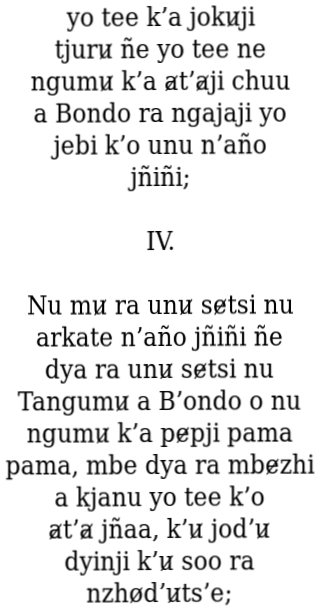

In [ ]:
dataset[2]["images"][0]

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
custom_collator = UnslothVisionDataCollator(
    model=model,
    processor=processor,
    ignore_index=-100,
    max_seq_length=2048,
    train_on_responses_only=True,
    instruction_part = "User: ",
    response_part = RESPONSE_PATTERN,
    pad_to_multiple_of = 8,
)

In [ ]:
# @title Visualizer Collator Mask
def visualize_collator_masking(dataset, collator, processor, num_samples=3):
    """
    Apply the collator and visualize exactly what tokens are being masked.
    """
    for idx in range(min(num_samples, len(dataset))):
        # Get raw sample from dataset
        raw_sample = dataset[idx]

        # Apply the collator (this does the masking)
        # Collator expects a list of samples (batch)
        batch = collator([raw_sample])

        # Extract first item from batch
        input_ids = batch["input_ids"][0]
        labels = batch["labels"][0]

        # Convert to lists if tensors
        if hasattr(input_ids, 'tolist'):
            input_ids = input_ids.tolist()
        if hasattr(labels, 'tolist'):
            labels = labels.tolist()

        print(f"\n{'='*80}")
        print(f"SAMPLE {idx}")
        print(f"{'='*80}")

        # Find the transition point from masked (-100) to unmasked
        transition_idx = None
        for i, label in enumerate(labels):
            if label != -100:
                transition_idx = i
                break

        if transition_idx is None:
            print("⚠️  WARNING: Everything is masked! No training tokens found!")
            print(f"Total tokens: {len(labels)}")
            print(f"All labels: {labels[:20]}...")  # Show first 20
            continue

        # Show context around the transition point
        context_window = 10
        start_idx = max(0, transition_idx - context_window)
        end_idx = min(len(input_ids), transition_idx + context_window)

        print(f"\nTransition point at token index: {transition_idx}")
        print(f"\nShowing tokens from {start_idx} to {end_idx}:")
        print(f"\n{'Index':<8} {'Token ID':<12} {'Label':<12} {'Masked?':<10} {'Decoded Token'}")
        print("-" * 80)

        for i in range(start_idx, end_idx):
            token_id = input_ids[i]
            label = labels[i]
            is_masked = "YES ❌" if label == -100 else "NO ✅"
            decoded = processor.tokenizer.decode([token_id])

            # Highlight the transition point
            marker = "  ← TRANSITION" if i == transition_idx else ""

            # Highlight the specific tokens we care about
            if token_id in [23, 92267, 93963, 93919]:
                marker += f"  ← Token {token_id}"

            print(f"{i:<8} {token_id:<12} {label:<12} {is_masked:<10} {repr(decoded):<20} {marker}")

        # Show full decoded sections
        print(f"\n{'─'*80}")
        print("MASKED SECTION (prompt - should NOT be trained on):")
        masked_tokens = [input_ids[i] for i, label in enumerate(labels) if label == -100]
        masked_text = processor.tokenizer.decode(masked_tokens)
        print(repr(masked_text))

        print(f"\n{'─'*80}")
        print("UNMASKED SECTION (response - SHOULD be trained on):")
        unmasked_tokens = [input_ids[i] for i, label in enumerate(labels) if label != -100]
        if unmasked_tokens:
            unmasked_text = processor.tokenizer.decode(unmasked_tokens)
            print(repr(unmasked_text))
            print(f"\n✅ Training on {len(unmasked_tokens)} tokens")
        else:
            print("⚠️  WARNING: No unmasked tokens! Nothing to train on!")

        print(f"\n{'─'*80}")
        print("FULL SEQUENCE:")
        full_text = processor.tokenizer.decode(input_ids)
        print(repr(full_text))

        # Statistics
        total_tokens = len(labels)
        masked_count = sum(1 for l in labels if l == -100)
        unmasked_count = total_tokens - masked_count
        print(f"\nStatistics:")
        print(f"  Total tokens: {total_tokens}")
        print(f"  Masked (prompt): {masked_count} ({masked_count/total_tokens*100:.1f}%)")
        print(f"  Unmasked (response): {unmasked_count} ({unmasked_count/total_tokens*100:.1f}%)")

        print(f"\n{'='*80}\n")

In [ ]:
visualize_collator_masking(dataset, custom_collator, processor, num_samples=1)


SAMPLE 0

Transition point at token index: 174

Showing tokens from 164 to 184:

Index    Token ID     Label        Masked?    Decoded Token
--------------------------------------------------------------------------------
164      100295       -100         YES ❌      '<|IMAGE_PLACEHOLDER|>' 
165      100295       -100         YES ❌      '<|IMAGE_PLACEHOLDER|>' 
166      101306       -100         YES ❌      '<|IMAGE_END|>'      
167      93972        -100         YES ❌      'O'                  
168      2497         -100         YES ❌      'CR'                 
169      93963        -100         YES ❌      ':'                    ← Token 93963
170      23           -100         YES ❌      '\n'                   ← Token 23
171      92267        -100         YES ❌      'Assistant'            ← Token 92267
172      93963        -100         YES ❌      ':'                    ← Token 93963
173      23           -100         YES ❌      '\n'                   ← Token 23
174      93941        

<a name="Train"></a>
### Train the model
We use wandb for tracking progress and also its a good time to sign up to Huggingface. Please fill out with your own keys.

In [ ]:
import wandb
from huggingface_hub import login

wandb.login(key=WANDB_KEY)
login(HF_KEY, add_to_git_credential=True)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lsjcp (tachiwin) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
timeout_callback = ColabTimeoutCallback(
    runtime_start_time=SESSION_START_TIME,
    total_training_minutes=MAX_SESSION_TIME,
    buffer_minutes=10,
    save_steps=SAVE_STEPS,
    margin_steps=20,
    wipe_delay_steps=20,
    checkpoint_dir=OUTPUT_DIR,
)

In [ ]:
from trl import SFTTrainer, SFTConfig
from unsloth.trainer import UnslothVisionDataCollator

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = processor.tokenizer,
    data_collator = custom_collator,
    train_dataset = dataset,
    #callbacks=[timeout_callback,],
    args = SFTConfig(
        per_device_train_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = ACCUM_STEPS, # Use GA to mimic batch size!
        warmup_steps = warmup_steps,
        max_steps = total_steps,
        learning_rate = LR,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = OUTPUT_DIR,
        logging_steps=LOGGING_STEPS,
        report_to="wandb",
        run_name=RUN_NAME,
        save_strategy="steps",
        save_steps=SAVE_STEPS,
        save_total_limit=1,
        push_to_hub=True,
        hub_model_id=CHECKPOINTS_REPO,
        hub_strategy="checkpoint",
        hub_private_repo=False,
        logging_first_step=True,

        # For vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
    ),
)


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-80GB. Max memory = 79.251 GB.
1.816 GB of memory reserved.


if you are using a T4 free instance to train and get ran out time, you can resume the next day by setting RESUME to True, but mind you have to keep the setting to push the checkpoints to a different repo than the final repo for weights.


In [ ]:
# @title Enable this is you want to resume from existing checkpoint
if RESUME:
  from huggingface_hub import snapshot_download
  # Download only the last-checkpoint folder
  local_checkpoint_dir = snapshot_download(
      repo_id=CHECKPOINTS_REPO,
      repo_type="model",
      allow_patterns="last-checkpoint/*",  # Only download this folder
      local_dir=CHECKPOINTS_DIR
  )

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

last-checkpoint/optimizer.pt:   0%|          | 0.00/2.48G [00:00<?, ?B/s]

last-checkpoint/model.safetensors:   0%|          | 0.00/1.92G [00:00<?, ?B/s]

configuration_paddleocr_vl.py: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

last-checkpoint/tokenizer.model:   0%|          | 0.00/1.61M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

last-checkpoint/training_args.bin:   0%|          | 0.00/6.42k [00:00<?, ?B/s]

trainer_state.json: 0.00B [00:00, ?B/s]

In [ ]:
# @title Train or Resume

if not RESUME:
  trainer_stats = trainer.train()
else:
  LAST_CHECKPOINT = f"{local_checkpoint_dir}/last-checkpoint"
  print(f"Resuming training from checkpoint: {LAST_CHECKPOINT}")
  trainer_stats = trainer.train(resume_from_checkpoint=LAST_CHECKPOINT)

Resuming training from checkpoint: /content/checkpoints/last-checkpoint


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 49,689 | Num Epochs = 2 | Total steps = 3,104
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 958,588,736 of 958,588,736 (100.00% trained)


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
2010,0.129000
2020,0.173400
2030,0.190700
2040,0.139000
2050,0.105300
2060,0.175800
2070,0.118600
2080,0.128300
2090,0.129400
2100,0.103900


train/epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▇▇▇▇▇▇█████
train/global_step,▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇██
train/grad_norm,▅▄▇▆▅▃▆▃▂▃▅▄█▃▃▃▂▅▄█▄▄▃▃▂▃▃▃▄▃▃▄▂▅▁▄▂▃▂▁
train/learning_rate,██▇▇▇▆▆▆▆▅▅▅▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train/loss,▆▃▄▄▃▆▂▃▄█▇▃▅▅▂▁▃▃▂▂▂▂▂▂▇▆▂▃▃▁▃▂▂▂▄▁▄▂▂▂
total_flos,2.4232838290224538e+17
train/epoch,1.99879
train/global_step,3104
train/grad_norm,4.28125
train/learning_rate,0.0
train/loss,0.0915


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

3982.0345 seconds used for training.
66.37 minutes used for training.
Peak reserved memory = 11.664 GB.
Peak reserved memory for training = 9.848 GB.
Peak reserved memory % of max memory = 14.718 %.
Peak reserved memory for training % of max memory = 12.426 %.


In [ ]:
print(f"Model dtype: {model.dtype}")
for name, param in model.named_parameters():
    print(f"Parameter: {name}, Dtype: {param.dtype}")
    break # Just show the first one to confirm

Model dtype: torch.bfloat16
Parameter: mlp_AR.pre_norm.weight, Dtype: torch.bfloat16


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

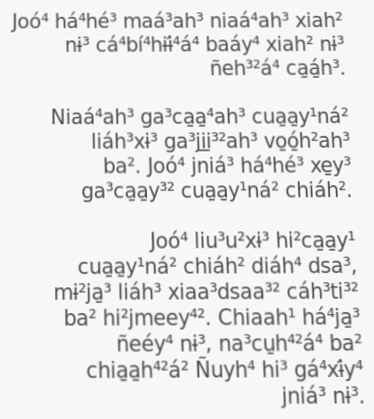

In [ ]:
img = dataset[999]['images'][0]
img

In [ ]:
#FastVisionModel.for_inference(model) # Enable for inference!

instruction = "OCR:"
messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]

text_prompt = processor.tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
    )

inputs = processor(
    img,
    text_prompt,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens=128,
                   use_cache=False)
#

Joó⁴ há⁴hé³ maá³ah³ niaá⁴ah³ xiah² nɨ³ cá⁴bí⁴hɨɨ́⁴á⁴ baáy⁴ xiah² nɨ³ ñeh³²á⁴ ca̱á̱h³. Niaá⁴ah³ ga³ca̱a̱⁴ah³ cua̱a̱y¹ná² liáh³xɨ³ ga³ji̱i


In [ ]:
model = model.half()
model.eval()

<a name="Save"></a>
### Saving, loading finetuned models
Now we save the final model and tokenizer to the HF, mind that as we are performing a full finetune and not LoRA, we do not need to merge.

In [ ]:
model.push_to_hub(FINAL_REPO) # Online saving
processor.tokenizer.push_to_hub(FINAL_REPO) # Online saving

README.md:   0%|          | 0.00/562 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ugh_vq6/model.safetensors:   2%|2         | 41.9MB / 1.92GB            

Saved model to https://huggingface.co/tachiwin/PaddleOCR-VL-1_5-Tachiwin


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...p0u41mv1_/tokenizer.model: 100%|##########| 1.61MB / 1.61MB            

  ...mp0u41mv1_/tokenizer.json: 100%|##########| 11.2MB / 11.2MB            

CommitInfo(commit_url='https://huggingface.co/tachiwin/PaddleOCR-VL-1_5-Tachiwin/commit/2c97a18a46bb793d5a37f887dad8cbcddc98af87', commit_message='Upload tokenizer', commit_description='', oid='2c97a18a46bb793d5a37f887dad8cbcddc98af87', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tachiwin/PaddleOCR-VL-1_5-Tachiwin', endpoint='https://huggingface.co', repo_type='model', repo_id='tachiwin/PaddleOCR-VL-1_5-Tachiwin'), pr_revision=None, pr_num=None)

# Tachiwin
### May the indigenous languages never be lost.

In the loving memory of _Fidencio Hernández_

Know more about Tachiwin and the indigenous languages of México at https://tachiwin.org



```

     000000000
   000       000
  00 /\-----/\ 00
 00  \/     \/\ 00   ________
00  /  ^^   ^^ \ 00 !___  ___!
0   ! (0)  (0) !  0    | ||                  ()          ()
00  \/ /  / / /\ 00    | || ____  __  __  __ __ __ __ __ __ __ __
 00  \/  / / /  00     | ||  _|| // \ ||__|| || || || || || ||\||
  00 |\(())_/  00      | || / || ||   ||--|| || \\ || // || ||\||
   000|     \000       | || \_|| \\_/ ||  || ||  \//\\/  || || \|
     000000000        -------- ########################## -------

```

